# Notebook 02: Analisis Exploratorio de Datos (EDA)

## Objetivos

1. Entender la calidad y estructura de los datos
2. Identificar patrones entre contactos que respondieron vs los que no
3. Analizar el funnel de outreach (LinkedIn + email)
4. Explorar las campanas y lineas de producto
5. Justificar la eleccion de metricas de evaluacion

## Datos de entrada

| Archivo | Contenido |
|---------|----------|
| `modeling_dataset_raw.parquet` | 10,946 contactos con features + target |
| `conversation_analytics_ES.parquet` | 11,517 conversaciones (funnel, timing) |
| `daily_analytics_ES.parquet` | 310 dias de metricas agregadas |
| `replies_analytics_ES.parquet` | Respuestas mensuales por canal |

## Imports y Configuracion

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = 'plotly_white'

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from scipy import stats

# Rutas
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
WORKING_DATA = os.path.join(PROJECT_ROOT, '..', '_working', 'data')

# Paleta de colores consistente
COLOR_POS = '#2ecc71'   # Verde para positivos (respondieron)
COLOR_NEG = '#e74c3c'   # Rojo para negativos
COLOR_ACCENT = '#3498db' # Azul acento
COLORS_2 = [COLOR_NEG, COLOR_POS]

In [2]:
# Cargar datos
df = pd.read_parquet(os.path.join(WORKING_DATA, 'modeling_dataset_raw.parquet'))
conv = pd.read_parquet(os.path.join(WORKING_DATA, 'conversation_analytics_ES.parquet'))
daily = pd.read_parquet(os.path.join(WORKING_DATA, 'daily_analytics_ES.parquet'))
replies = pd.read_parquet(os.path.join(WORKING_DATA, 'replies_analytics_ES.parquet'))

print(f'Dataset de modelado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Conversation analytics: {conv.shape[0]:,} filas')
print(f'Daily analytics: {daily.shape[0]} filas')
print(f'Replies analytics: {replies.shape[0]} filas')

Dataset de modelado: 10,946 filas x 47 columnas
Conversation analytics: 11,517 filas
Daily analytics: 310 filas
Replies analytics: 13 filas


---
## 2.1 Calidad de datos y vision general

In [3]:
# Porcentaje de nulos por columna (ordenado)
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
non_null_pct = (100 - null_pct).round(1)

# Columnas con datos vs completamente vacias
empty_cols = null_pct[null_pct == 100].index.tolist()
usable_cols = null_pct[null_pct < 100].index.tolist()

print(f'Columnas con datos: {len(usable_cols)}')
print(f'Columnas completamente vacias: {len(empty_cols)}')
if empty_cols:
    print(f'  -> {empty_cols}')
    print('  (Se eliminaran en NB03)')

Columnas con datos: 41
Columnas completamente vacias: 6
  -> ['Gender', 'Revenue', 'Jobs posted from LinkedIn', 'ai_FIT_INFRA', 'ai_FIT_WORKPLACE', 'ai_FIT_MAITE']
  (Se eliminaran en NB03)


In [4]:
# Visualizacion de completitud por columna
cols_to_show = [c for c in df.columns if c not in empty_cols 
                and c not in ['LinkedIn profile ID', 'Full name', 'First name', 'Last name']]

completeness = pd.DataFrame({
    'columna': cols_to_show,
    'pct_datos': [non_null_pct[c] for c in cols_to_show]
}).sort_values('pct_datos')

fig = px.bar(
    completeness, x='pct_datos', y='columna', orientation='h',
    title='Completitud de datos por columna (%)',
    labels={'pct_datos': '% no nulo', 'columna': ''},
    color='pct_datos',
    color_continuous_scale='RdYlGn',
    range_color=[0, 100],
)
fig.update_layout(height=700, showlegend=False)
fig.show()

In [5]:
# Patron de nulos: se correlacionan con el target?
key_features = ['ai_SENIORITY', 'ai_DEPARTMENT', 'ai_FIT', 'ai_Contact_score',
                'Industry', 'Number of employees', 'Years in role', 'Number of connections',
                'Technologies used', 'ai_CONTACT_REPORT', 'ai_COMPANY_REPORT']

null_vs_target = []
for col in key_features:
    if col in df.columns:
        has_data = df[col].notna()
        rate_with = df.loc[has_data, 'target_replied'].mean()
        rate_without = df.loc[~has_data, 'target_replied'].mean() if (~has_data).sum() > 0 else np.nan
        null_vs_target.append({
            'columna': col,
            'pct_no_nulo': has_data.mean() * 100,
            'reply_rate_con_dato': rate_with * 100,
            'reply_rate_sin_dato': rate_without * 100,
        })

null_target_df = pd.DataFrame(null_vs_target).round(1)
print('=== Tasa de respuesta segun disponibilidad de datos ===')
print(null_target_df.to_string(index=False))
print(f'\nTasa global: {df["target_replied"].mean()*100:.1f}%')

=== Tasa de respuesta segun disponibilidad de datos ===
              columna  pct_no_nulo  reply_rate_con_dato  reply_rate_sin_dato
         ai_SENIORITY         93.0                  8.5                  0.3
        ai_DEPARTMENT         92.8                  8.5                  0.4
               ai_FIT         93.1                  8.5                  0.5
     ai_Contact_score         99.6                  7.9                  8.9
             Industry         89.3                  8.4                  3.4
  Number of employees         87.8                  8.5                  3.7
        Years in role         82.4                  9.2                  1.7
Number of connections         92.9                  8.4                  1.0
    Technologies used         15.0                 10.0                  7.5
    ai_CONTACT_REPORT         42.6                 14.9                  2.7
    ai_COMPANY_REPORT         91.1                  8.5                  1.3

Tasa global: 7.9%


---
## 2.2 Distribucion del target

In [6]:
# Target distribution
target_counts = df['target_replied'].value_counts().sort_index()

fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'bar'}, {'type': 'pie'}]],
                    subplot_titles=['Conteo', 'Proporcion'])

fig.add_trace(
    go.Bar(x=['No respondio', 'Respondio'], y=target_counts.values,
           marker_color=COLORS_2, text=target_counts.values, textposition='auto'),
    row=1, col=1
)

fig.add_trace(
    go.Pie(labels=['No respondio', 'Respondio'], values=target_counts.values,
           marker_colors=COLORS_2, textinfo='percent+label', hole=0.4),
    row=1, col=2
)

fig.update_layout(title='Distribucion de la variable objetivo (target_replied)',
                  height=400, showlegend=False)
fig.show()

print(f'Clase desbalanceada: {df["target_replied"].mean():.1%} positivos')
print(f'Ratio negativo:positivo = {(df["target_replied"]==0).sum()}:{df["target_replied"].sum()} = '
      f'{(df["target_replied"]==0).sum() / max(df["target_replied"].sum(), 1):.0f}:1')

Clase desbalanceada: 7.9% positivos
Ratio negativo:positivo = 10081:865 = 12:1


In [7]:
# Desglose por canal
channel_data = pd.DataFrame({
    'Canal': ['Solo LinkedIn', 'Solo Email', 'Ambos', 'Total respondieron'],
    'Contactos': [
        ((df['target_replied_linkedin'] == 1) & (df['target_replied_email'] == 0)).sum(),
        ((df['target_replied_email'] == 1) & (df['target_replied_linkedin'] == 0)).sum(),
        ((df['target_replied_linkedin'] == 1) & (df['target_replied_email'] == 1)).sum(),
        df['target_replied'].sum(),
    ]
})
print('=== Respuestas por canal ===')
print(channel_data.to_string(index=False))

=== Respuestas por canal ===
             Canal  Contactos
     Solo LinkedIn        552
        Solo Email        313
             Ambos          0
Total respondieron        865


---
## 2.3 Funnel de outreach

Analizamos el embudo completo de prospecting usando los datos diarios agregados.

In [8]:
# Funnel totales
funnel_data = {
    'Audiencia total': daily['total_audience'].max(),
    'Contactados': daily['total_contacted'].max(),
    'LinkedIn enviados': daily['linkedin_messages_sent'].sum(),
    'Conexiones aceptadas': daily['linkedin_connections_accepted'].sum(),
    'LinkedIn replies': daily['linkedin_replies'].sum(),
    'Email enviados': daily['email_sent'].sum(),
    'Email abiertos': daily['email_opened'].sum(),
    'Email clicks': daily['email_clicked'].sum(),
    'Email replies': daily['email_replies'].sum(),
}

print('=== Metricas acumuladas del funnel ===')
for k, v in funnel_data.items():
    print(f'  {k}: {v:,.0f}')

=== Metricas acumuladas del funnel ===
  Audiencia total: 23,674
  Contactados: 465
  LinkedIn enviados: 20,385
  Conexiones aceptadas: 2,784
  LinkedIn replies: 983
  Email enviados: 30,423
  Email abiertos: 0
  Email clicks: 0
  Email replies: 595


In [9]:
# Funnel chart - LinkedIn
linkedin_funnel = pd.DataFrame({
    'Etapa': ['Mensajes enviados', 'Conexiones aceptadas', 'Respuestas'],
    'Valor': [
        daily['linkedin_messages_sent'].sum(),
        daily['linkedin_connections_accepted'].sum(),
        daily['linkedin_replies'].sum(),
    ]
})

fig_ln = go.Figure(go.Funnel(
    y=linkedin_funnel['Etapa'], x=linkedin_funnel['Valor'],
    textinfo='value+percent initial',
    marker_color=['#3498db', '#2ecc71', '#27ae60'],
))
fig_ln.update_layout(title='Funnel LinkedIn', height=350)
fig_ln.show()

# Funnel chart - Email
email_funnel = pd.DataFrame({
    'Etapa': ['Enviados', 'Abiertos', 'Clicks', 'Respuestas'],
    'Valor': [
        daily['email_sent'].sum(),
        daily['email_opened'].sum(),
        daily['email_clicked'].sum(),
        daily['email_replies'].sum(),
    ]
})

fig_em = go.Figure(go.Funnel(
    y=email_funnel['Etapa'], x=email_funnel['Valor'],
    textinfo='value+percent initial',
    marker_color=['#e74c3c', '#f39c12', '#e67e22', '#d35400'],
))
fig_em.update_layout(title='Funnel Email', height=350)
fig_em.show()

In [10]:
# Serie temporal de actividad diaria
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Mensajes enviados por dia', 'Respuestas por dia'],
                    vertical_spacing=0.1)

fig.add_trace(
    go.Scatter(x=daily['date'], y=daily['linkedin_messages_sent'],
               name='LinkedIn enviados', line=dict(color='#3498db')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=daily['date'], y=daily['email_sent'],
               name='Email enviados', line=dict(color='#e74c3c')),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=daily['date'], y=daily['linkedin_replies'],
               name='LinkedIn replies', line=dict(color='#2ecc71')),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(x=daily['date'], y=daily['email_replies'],
               name='Email replies', line=dict(color='#f39c12')),
    row=2, col=1
)

fig.update_layout(height=500, title='Actividad diaria de outreach')
fig.show()

In [11]:
# Tendencia mensual de respuestas (replies_analytics)
fig = go.Figure()
fig.add_trace(go.Bar(x=replies['timestamp'], y=replies['linkedin'],
                     name='LinkedIn', marker_color='#3498db'))
fig.add_trace(go.Bar(x=replies['timestamp'], y=replies['email'],
                     name='Email', marker_color='#e74c3c'))

fig.update_layout(
    title='Respuestas mensuales por canal',
    barmode='group', height=400,
    xaxis_title='Mes', yaxis_title='Respuestas'
)
fig.show()

---
## 2.4 Perfil de converters vs non-converters

Comparamos las caracteristicas de los contactos que respondieron (target=1) vs los que no (target=0).

In [12]:
# Helper: comparar distribucion de una variable categorica entre converters y non-converters
def plot_categorical_comparison(df, col, top_n=10, title=None):
    """Barras agrupadas mostrando tasa de respuesta por categoria."""
    if df[col].notna().sum() == 0:
        print(f'{col}: sin datos')
        return
    
    # Calcular tasa de respuesta por categoria
    grp = df.groupby(col)['target_replied'].agg(['sum', 'count']).reset_index()
    grp.columns = [col, 'respondieron', 'total']
    grp['tasa_respuesta'] = (grp['respondieron'] / grp['total'] * 100).round(1)
    grp = grp.sort_values('total', ascending=False).head(top_n)
    
    fig = make_subplots(rows=1, cols=2, 
                        subplot_titles=['Volumen por categoria', 'Tasa de respuesta (%)'],
                        column_widths=[0.5, 0.5])
    
    fig.add_trace(
        go.Bar(y=grp[col], x=grp['total'], orientation='h',
               name='Total', marker_color=COLOR_ACCENT,
               text=grp['total'], textposition='auto'),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Bar(y=grp[col], x=grp['tasa_respuesta'], orientation='h',
               name='Tasa respuesta', marker_color=COLOR_POS,
               text=grp['tasa_respuesta'].apply(lambda x: f'{x:.1f}%'), textposition='auto'),
        row=1, col=2
    )
    
    if title is None:
        title = f'Analisis de {col}'
    fig.update_layout(title=title, height=max(300, top_n * 35), showlegend=False)
    fig.show()
    
    return grp

In [13]:
# Helper: comparar distribucion numerica entre converters y non-converters
def plot_numeric_comparison(df, col, title=None, log_scale=False):
    """Histogramas superpuestos + test estadistico."""
    data = df[df[col].notna()].copy()
    if len(data) == 0:
        print(f'{col}: sin datos')
        return
    
    pos = data[data['target_replied'] == 1][col]
    neg = data[data['target_replied'] == 0][col]
    
    # Test Mann-Whitney
    if len(pos) > 5 and len(neg) > 5:
        stat, pval = stats.mannwhitneyu(pos, neg, alternative='two-sided')
        sig = 'SI' if pval < 0.05 else 'NO'
    else:
        pval, sig = np.nan, 'N/A'
    
    fig = go.Figure()
    fig.add_trace(go.Histogram(x=neg, name='No respondio', opacity=0.7,
                               marker_color=COLOR_NEG, nbinsx=40))
    fig.add_trace(go.Histogram(x=pos, name='Respondio', opacity=0.7,
                               marker_color=COLOR_POS, nbinsx=40))
    
    if title is None:
        title = col
    fig.update_layout(
        title=f'{title} (p={pval:.4f}, significativo: {sig})',
        barmode='overlay', height=350,
        xaxis_title=col, yaxis_title='Frecuencia',
    )
    if log_scale:
        fig.update_xaxes(type='log')
    fig.show()
    
    print(f'  Mediana respondieron: {pos.median():.1f} | No respondieron: {neg.median():.1f}')

### 2.4.1 ai_SENIORITY (nivel jerarquico)

In [14]:
plot_categorical_comparison(df, 'ai_SENIORITY',
                           title='Nivel jerarquico (ai_SENIORITY) vs tasa de respuesta')

,ai_SENIORITY,respondieron,total,tasa_respuesta
1,DIRECTOR,240,2988,8.0
3,LEAD,145,1953,7.4
2,JR,157,1869,8.4
4,MANAGER,167,1473,11.3
0,CLEVEL,93,1251,7.4
6,OWNER,16,360,4.4
5,OTHER,30,180,16.7
8,VP,10,83,12.0
7,TRAINEE,5,18,27.8


### 2.4.2 ai_DEPARTMENT

In [15]:
plot_categorical_comparison(df, 'ai_DEPARTMENT',
                           title='Departamento (ai_DEPARTMENT) vs tasa de respuesta')

,ai_DEPARTMENT,respondieron,total,tasa_respuesta
1,IT,336,3763,8.9
2,OPerations,167,2179,7.7
3,Other,160,2078,7.7
4,Sales & MKT,143,1292,11.1
0,Finance,56,842,6.7


### 2.4.3 ai_Contact_score

In [16]:
plot_categorical_comparison(df, 'ai_Contact_score',
                           title='Puntuacion del contacto (ai_Contact_score) vs tasa de respuesta')

,ai_Contact_score,respondieron,total,tasa_respuesta
0,Disqualified,334,4033,8.3
1,High,240,3147,7.6
3,Medium,130,1418,9.2
2,Low,135,1266,10.7
4,Missing Data,22,1037,2.1


### 2.4.4 ai_Company_score

In [17]:
plot_categorical_comparison(df, 'ai_Company_score',
                           title='Puntuacion de empresa (ai_Company_score) vs tasa de respuesta')

,ai_Company_score,respondieron,total,tasa_respuesta
1,High,389,4679,8.3
3,Medium,209,2368,8.8
2,Low,199,2237,8.9
4,Missing Data,32,540,5.9
0,Disqualified,10,140,7.1


### 2.4.5 ai_FIT (puntuacion general)

In [18]:
# Simplificar ai_FIT a categorias limpias
def simplify_fit(val):
    if pd.isna(val):
        return np.nan
    val = str(val).upper()
    if 'APROBADO' in val and 'DESAPROBADO' not in val:
        return 'APROBADO'
    if 'DESAPROBADO' in val:
        return 'DESAPROBADO'
    if 'SI' == val.strip():
        return 'APROBADO'
    if 'NO' == val.strip():
        return 'DESAPROBADO'
    if 'DUDA' in val:
        return 'DUDA'
    if 'COMPETITOR' in val:
        return 'COMPETITOR'
    return 'OTRO'

df['ai_FIT_clean'] = df['ai_FIT'].apply(simplify_fit)
plot_categorical_comparison(df, 'ai_FIT_clean',
                           title='FIT general simplificado vs tasa de respuesta')

,ai_FIT_clean,respondieron,total,tasa_respuesta
0,APROBADO,751,9246,8.1
2,DESAPROBADO,53,441,12.0
4,OTRO,28,251,11.2
3,DUDA,28,246,11.4
1,COMPETITOR,1,5,20.0


### 2.4.6 ai_FIT_DATA (unico FIT por producto con datos suficientes)

In [19]:
# ai_FIT_DATA tiene 93% de datos con valores: SI, NO, COMPETITOR, DUDA
plot_categorical_comparison(df, 'ai_FIT_DATA',
                           title='FIT DATA (Power BI, Fabric) vs tasa de respuesta')

,ai_FIT_DATA,respondieron,total,tasa_respuesta
3,SI,820,9796,8.4
0,COMPETITOR,18,232,7.8
2,NO,21,145,14.5
1,DUDA,3,15,20.0


### 2.4.7 ai_Microsoft (usa tecnologia Microsoft)

In [20]:
plot_categorical_comparison(df, 'ai_Microsoft',
                           title='Usa Microsoft? vs tasa de respuesta')

,ai_Microsoft,respondieron,total,tasa_respuesta
2,1.0,605,7097,8.5
1,0.0,168,2022,8.3
0,-1.0,23,215,10.7


### 2.4.8 Industry (sector de la empresa)

In [21]:
plot_categorical_comparison(df, 'Industry', top_n=20,
                           title='Top 20 industrias por volumen y tasa de respuesta')

,Industry,respondieron,total,tasa_respuesta
61,Government Administration,31,569,5.4
167,Telecommunications,10,406,2.5
144,Retail,27,386,7.0
54,Food and Beverage Services,22,366,6.0
25,Construction,25,361,6.9
66,Higher Education,47,323,14.6
120,Pharmaceutical Manufacturing,20,288,6.9
49,Financial Services,23,265,8.7
68,Hospitals and Health Care,15,229,6.6
67,Hospitality,13,226,5.8


### 2.4.9 Variables numericas

In [22]:
plot_numeric_comparison(df, 'Number of employees', 
                       title='Numero de empleados', log_scale=True)

  Mediana respondieron: 762.5 | No respondieron: 616.0


In [23]:
plot_numeric_comparison(df, 'Years in role', title='Anos en el puesto')

  Mediana respondieron: 2.4 | No respondieron: 3.5


In [24]:
plot_numeric_comparison(df, 'Number of connections', 
                       title='Numero de conexiones LinkedIn', log_scale=True)

  Mediana respondieron: 899.0 | No respondieron: 517.0


In [25]:
plot_numeric_comparison(df, 'Year founded', title='Ano de fundacion de la empresa')

  Mediana respondieron: 1983.0 | No respondieron: 1978.0


In [26]:
# Headcount growth comparisons
for col in ['Yearly headcount growth', 'Two years headcount growth']:
    if df[col].notna().sum() > 100:
        plot_numeric_comparison(df, col, title=col)

  Mediana respondieron: 5.0 | No respondieron: 5.0


  Mediana respondieron: 14.0 | No respondieron: 13.0


### 2.4.10 Resumen estadistico: converters vs non-converters

In [27]:
# Tabla resumen de diferencias significativas
numeric_features = ['Years in role', 'Years in company', 'Number of connections',
                    'Number of employees', 'Year founded',
                    'Yearly headcount growth', 'Two years headcount growth']

summary_rows = []
for col in numeric_features:
    data = df[df[col].notna()]
    pos = data[data['target_replied'] == 1][col]
    neg = data[data['target_replied'] == 0][col]
    if len(pos) > 5 and len(neg) > 5:
        stat, pval = stats.mannwhitneyu(pos, neg, alternative='two-sided')
        summary_rows.append({
            'Feature': col,
            'Mediana (respondio)': pos.median(),
            'Mediana (no respondio)': neg.median(),
            'p-value': pval,
            'Significativo': 'SI' if pval < 0.05 else 'NO',
        })

summary_df = pd.DataFrame(summary_rows)
print('=== Test Mann-Whitney: converters vs non-converters ===')
print(summary_df.to_string(index=False))

=== Test Mann-Whitney: converters vs non-converters ===
                   Feature  Mediana (respondio)  Mediana (no respondio)      p-value Significativo
             Years in role                2.375                    3.50 9.448630e-19            SI
          Years in company                4.330                    5.83 9.367421e-10            SI
     Number of connections              899.000                  517.00 2.247029e-38            SI
       Number of employees              762.500                  616.00 1.450118e-05            SI
              Year founded             1983.000                 1978.00 3.193280e-02            SI
   Yearly headcount growth                5.000                    5.00 5.625130e-01            NO
Two years headcount growth               14.000                   13.00 5.602072e-01            NO


In [28]:
# Chi-square tests para categoricas
cat_features = ['ai_SENIORITY', 'ai_DEPARTMENT', 'ai_Contact_score', 
                'ai_Company_score', 'ai_FIT_clean', 'ai_FIT_DATA', 'ai_Microsoft']

chi2_rows = []
for col in cat_features:
    data = df[df[col].notna()]
    if data[col].nunique() < 2:
        continue
    ct = pd.crosstab(data[col], data['target_replied'])
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2, pval, dof, expected = stats.chi2_contingency(ct)
        chi2_rows.append({
            'Feature': col,
            'Chi2': chi2,
            'p-value': pval,
            'Significativo': 'SI' if pval < 0.05 else 'NO',
        })

chi2_df = pd.DataFrame(chi2_rows)
print('=== Test Chi-cuadrado: asociacion con target ===')
print(chi2_df.to_string(index=False))

=== Test Chi-cuadrado: asociacion con target ===
         Feature      Chi2      p-value Significativo
    ai_SENIORITY 53.939855 7.091431e-09            SI
   ai_DEPARTMENT 19.237995 7.056770e-04            SI
ai_Contact_score 65.155422 2.386332e-13            SI
ai_Company_score  5.883671 2.080058e-01            NO
    ai_FIT_clean 14.510696 5.831466e-03            SI
     ai_FIT_DATA  9.618228 2.210631e-02            SI
    ai_Microsoft  1.422324 4.910732e-01            NO


---
## 2.5 Analisis de campanas

Extraemos la linea de producto y el canal de cada campana a partir del nombre.

In [29]:
# Parsear campaignName para extraer producto y canal
def extract_product(name):
    """Extrae la linea de producto del nombre de campana."""
    name_upper = str(name).upper()
    if 'MAITE' in name_upper or 'GOB' in name_upper or 'ADOP' in name_upper:
        return 'MAITE'
    if ' IA' in name_upper or 'IA ' in name_upper:
        return 'IA'
    if 'WORKPLACE' in name_upper:
        return 'WORKPLACE'
    if 'DATA' in name_upper:
        return 'DATA'
    if 'INFRA' in name_upper:
        return 'INFRA'
    if 'COLABORA' in name_upper or 'COMUNICA' in name_upper or 'CI' in name_upper:
        return 'COLABORA'
    if 'CONNECTION' in name_upper or 'CONNECT' in name_upper:
        return 'CONNECTION'  # Solo conexion, sin producto especifico
    return 'OTRO'

def extract_channel(name):
    """Extrae el canal del nombre de campana."""
    name_upper = str(name).upper()
    if 'LINKEDIN' in name_upper or 'LKN' in name_upper:
        return 'LinkedIn'
    if 'MAIL' in name_upper or 'EMAIL' in name_upper:
        return 'Email'
    if 'CONNECTION' in name_upper:
        return 'LinkedIn'
    return 'Otro'

conv['product'] = conv['campaignName'].apply(extract_product)
conv['channel'] = conv['campaignName'].apply(extract_channel)

# Crear target en conversation analytics
conv['target_replied'] = ((conv['linkedinReplied'] > 0) | (conv['emailReplied'] > 0)).astype(int)

print('=== Campanas por producto ===')
print(conv['product'].value_counts())
print(f'\n=== Campanas por canal ===')
print(conv['channel'].value_counts())

=== Campanas por producto ===
product
OTRO          3114
MAITE         2180
WORKPLACE     1561
COLABORA      1553
DATA          1353
INFRA          991
IA             753
CONNECTION      12
Name: count, dtype: int64

=== Campanas por canal ===
channel
Email       9287
LinkedIn    1967
Otro         263
Name: count, dtype: int64


In [30]:
# Tasa de respuesta por producto
product_stats = conv.groupby('product')['target_replied'].agg(['sum', 'count', 'mean']).reset_index()
product_stats.columns = ['Producto', 'Respuestas', 'Conversaciones', 'Tasa']
product_stats['Tasa_pct'] = (product_stats['Tasa'] * 100).round(1)
product_stats = product_stats.sort_values('Conversaciones', ascending=False)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Volumen de conversaciones', 'Tasa de respuesta (%)'])

fig.add_trace(
    go.Bar(y=product_stats['Producto'], x=product_stats['Conversaciones'],
           orientation='h', marker_color=COLOR_ACCENT,
           text=product_stats['Conversaciones'], textposition='auto'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(y=product_stats['Producto'], x=product_stats['Tasa_pct'],
           orientation='h', marker_color=COLOR_POS,
           text=product_stats['Tasa_pct'].apply(lambda x: f'{x}%'), textposition='auto'),
    row=1, col=2
)

fig.update_layout(title='Conversion por linea de producto (nivel conversacion)',
                  height=400, showlegend=False)
fig.show()

print(product_stats[['Producto', 'Conversaciones', 'Respuestas', 'Tasa_pct']].to_string(index=False))

  Producto  Conversaciones  Respuestas  Tasa_pct
      OTRO            3114         808      25.9
     MAITE            2180         211       9.7
 WORKPLACE            1561          99       6.3
  COLABORA            1553         136       8.8
      DATA            1353          78       5.8
     INFRA             991          64       6.5
        IA             753          42       5.6
CONNECTION              12           6      50.0


In [31]:
# Tasa de respuesta por campana individual (scatter: volumen vs conversion)
campaign_stats = conv.groupby('campaignName').agg(
    conversaciones=('target_replied', 'count'),
    respuestas=('target_replied', 'sum'),
    tasa=('target_replied', 'mean'),
    producto=('product', 'first'),
    canal=('channel', 'first'),
).reset_index()
campaign_stats['tasa_pct'] = (campaign_stats['tasa'] * 100).round(1)

fig = px.scatter(
    campaign_stats, x='conversaciones', y='tasa_pct',
    color='producto', size='respuestas',
    hover_name='campaignName',
    title='Campanas: volumen vs tasa de conversion',
    labels={'conversaciones': 'Conversaciones', 'tasa_pct': 'Tasa respuesta (%)',
            'producto': 'Producto'},
    height=500,
)
fig.show()

In [32]:
# Canal: LinkedIn vs Email
channel_stats = conv.groupby('channel')['target_replied'].agg(['sum', 'count', 'mean']).reset_index()
channel_stats.columns = ['Canal', 'Respuestas', 'Conversaciones', 'Tasa']
channel_stats['Tasa_pct'] = (channel_stats['Tasa'] * 100).round(1)

print('=== Conversion por canal ===')
print(channel_stats.to_string(index=False))

=== Conversion por canal ===
   Canal  Respuestas  Conversaciones     Tasa  Tasa_pct
   Email         599            9287 0.064499       6.4
LinkedIn         759            1967 0.385867      38.6
    Otro          86             263 0.326996      32.7


---
## 2.6 Analisis de timing

Dia de la semana y mes en que se obtienen mejores tasas de respuesta.

In [33]:
# Dia de la semana
daily['day_of_week'] = daily['date'].dt.day_name()
daily['dow_num'] = daily['date'].dt.dayofweek

# Solo dias con actividad
active_days = daily[daily['linkedin_messages_sent'] + daily['email_sent'] > 0].copy()
active_days['reply_rate'] = (
    (active_days['linkedin_replies'] + active_days['email_replies']) /
    (active_days['linkedin_messages_sent'] + active_days['email_sent']).clip(lower=1)
) * 100

dow_stats = active_days.groupby(['dow_num', 'day_of_week']).agg(
    dias=('reply_rate', 'count'),
    tasa_media=('reply_rate', 'mean'),
    total_enviados=('linkedin_messages_sent', 'sum'),
).reset_index().sort_values('dow_num')

fig = go.Figure()
fig.add_trace(go.Bar(
    x=dow_stats['day_of_week'], y=dow_stats['tasa_media'].round(1),
    marker_color=COLOR_ACCENT,
    text=dow_stats['tasa_media'].round(1).apply(lambda x: f'{x}%'),
    textposition='auto'
))
fig.update_layout(title='Tasa de respuesta media por dia de la semana',
                  yaxis_title='Tasa respuesta (%)', height=400)
fig.show()

In [34]:
# Tendencia mensual
daily['month'] = daily['date'].dt.to_period('M').astype(str)
monthly = daily.groupby('month').agg(
    enviados=('linkedin_messages_sent', 'sum'),
    email_enviados=('email_sent', 'sum'),
    replies_ln=('linkedin_replies', 'sum'),
    replies_em=('email_replies', 'sum'),
).reset_index()
monthly['total_enviados'] = monthly['enviados'] + monthly['email_enviados']
monthly['total_replies'] = monthly['replies_ln'] + monthly['replies_em']
monthly['tasa'] = (monthly['total_replies'] / monthly['total_enviados'].clip(lower=1) * 100).round(1)

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Volumen mensual', 'Tasa de respuesta mensual (%)'])

fig.add_trace(
    go.Bar(x=monthly['month'], y=monthly['total_enviados'], name='Enviados',
           marker_color=COLOR_ACCENT),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=monthly['month'], y=monthly['total_replies'], name='Respuestas',
           marker_color=COLOR_POS),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=monthly['month'], y=monthly['tasa'], name='Tasa %',
               line=dict(color=COLOR_POS, width=3), mode='lines+markers'),
    row=2, col=1
)

fig.update_layout(title='Evolucion mensual del outreach', height=500)
fig.show()

---
## 2.7 Exploracion de campos de texto (preview para NLP)

Los campos `ai_CONTACT_REPORT`, `ai_COMPANY_REPORT` y `ai_MOMENTUM` contienen texto generado por IA 
que procesaremos con NLP en NB03. Aqui hacemos una exploracion basica.

In [35]:
# Disponibilidad de campos de texto
text_cols = ['ai_CONTACT_REPORT', 'ai_COMPANY_REPORT', 'ai_MOMENTUM']
for col in text_cols:
    non_null = df[col].notna().sum()
    pct = non_null / len(df) * 100
    if non_null > 0:
        lengths = df[col].dropna().str.len()
        print(f'{col}: {non_null:,} ({pct:.1f}%) | '
              f'longitud media: {lengths.mean():.0f} chars, '
              f'mediana: {lengths.median():.0f}, max: {lengths.max():,.0f}')
    else:
        print(f'{col}: {non_null} ({pct:.1f}%)')

ai_CONTACT_REPORT: 4,658 (42.6%) | longitud media: 2934 chars, mediana: 2902, max: 7,648
ai_COMPANY_REPORT: 9,970 (91.1%) | longitud media: 8106 chars, mediana: 8102, max: 15,475
ai_MOMENTUM: 1,755 (16.0%) | longitud media: 2295 chars, mediana: 2309, max: 4,219


In [36]:
# Longitud de texto vs target
for col in text_cols:
    if df[col].notna().sum() > 100:
        df[f'_len_{col}'] = df[col].str.len()
        plot_numeric_comparison(df, f'_len_{col}', 
                               title=f'Longitud de {col} (caracteres)')
        df.drop(columns=[f'_len_{col}'], inplace=True)

  Mediana respondieron: 2886.0 | No respondieron: 2905.0


  Mediana respondieron: 8011.0 | No respondieron: 8104.0


  Mediana respondieron: 2197.0 | No respondieron: 2325.0


In [37]:
# Muestras de texto: converters vs non-converters
for col in ['ai_COMPANY_REPORT', 'ai_MOMENTUM']:
    if df[col].notna().sum() > 10:
        print(f'\n{"="*60}')
        print(f'MUESTRAS DE {col}')
        print(f'{"="*60}')
        
        converters = df[(df['target_replied'] == 1) & (df[col].notna())]
        non_converters = df[(df['target_replied'] == 0) & (df[col].notna())]
        
        if len(converters) > 0:
            print(f'\n--- RESPONDIERON (muestra de {min(3, len(converters))}) ---')
            for _, row in converters.sample(min(3, len(converters)), random_state=42).iterrows():
                print(f'  [{row["Company name"]}] {str(row[col])[:300]}...')
                print()
        
        if len(non_converters) > 0:
            print(f'--- NO RESPONDIERON (muestra de {min(3, len(non_converters))}) ---')
            for _, row in non_converters.sample(min(3, len(non_converters)), random_state=42).iterrows():
                print(f'  [{row["Company name"]}] {str(row[col])[:300]}...')
                print()


MUESTRAS DE ai_COMPANY_REPORT



--- RESPONDIERON (muestra de 3) ---
  [Werfen] Informe ejecutivo (resumen accionable para outreach de Raona — Communication Hub sobre Microsoft 365)

1) Snapshot corto — datos verificados
- Nombre: Werfen
- Industria: Medical Equipment / Specialized Diagnostics (Hemostasis, Acute Care Diagnostics, Transfusion, Autoimmunity, Transplant)
- Origen ...

  [B. Braun Group] Informe ejecutivo (resumen de insights accionables para outreach comercial a B. Braun Group)

1) Resumen ejecutivo
B. Braun Group es una compañía familiar líder en tecnología médica con presencia global, con más de 65.000 empleados (corporate profile) y fuertes requerimientos regulatorios y operativ...

  [OPTICA UNIVERSITARIA] **Reporte de Información Relevante: Óptica Universitaria****1. Cono de la Empresa: Óptica & Audiología Universitaria**Óptica & Audiología Universitaria es una cadena de ópticas y audiología con una trayectoria de más de 30 años, dedicada a la distribución y comercialización de productos y servicio

---
## 2.8 Correlaciones entre features numericas

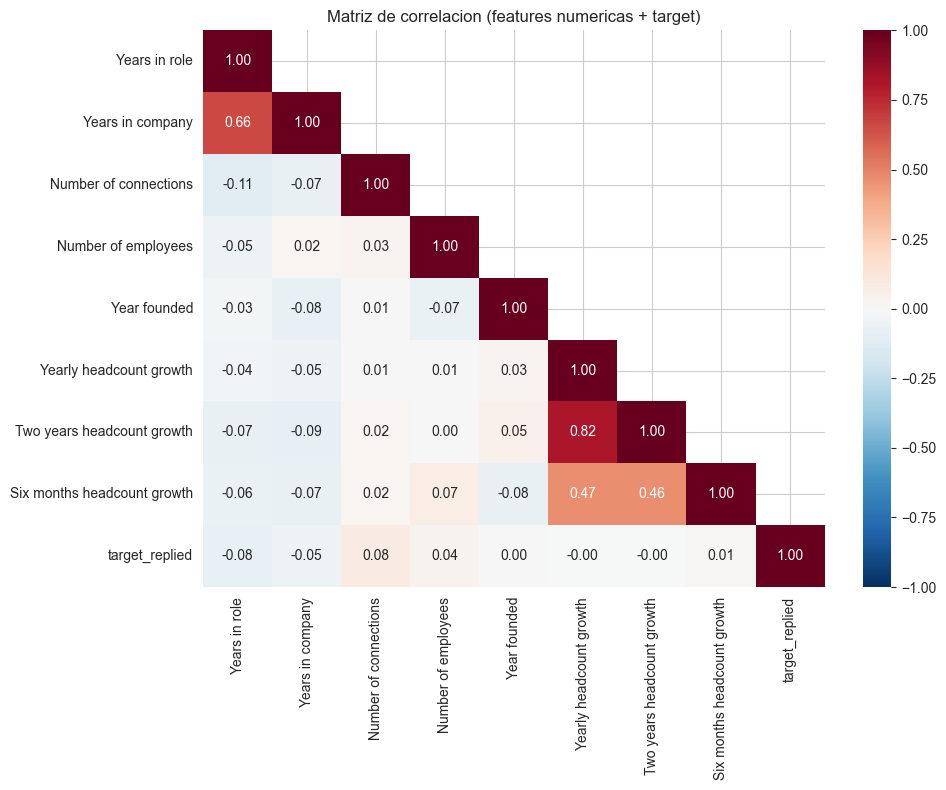


Pares con correlacion > 0.7:
  Yearly headcount growth <-> Two years headcount growth: 0.82


In [38]:
# Correlaciones
corr_cols = ['Years in role', 'Years in company', 'Number of connections',
             'Number of employees', 'Year founded',
             'Yearly headcount growth', 'Two years headcount growth',
             'Six months headcount growth', 'target_replied']
corr_cols = [c for c in corr_cols if c in df.columns and df[c].notna().sum() > 100]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax)
plt.title('Matriz de correlacion (features numericas + target)')
plt.tight_layout()
plt.show()

# Pares con alta correlacion
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))

if high_corr:
    print('\nPares con correlacion > 0.7:')
    for c1, c2, v in high_corr:
        print(f'  {c1} <-> {c2}: {v:.2f}')
else:
    print('\nNo hay pares con correlacion > 0.7')

---
## 2.9 Observaciones sobre los FIT scores por producto

Los FIT scores por producto individual (`ai_FIT_IA`, `ai_FIT_COLABORA`, `ai_FIT_INFRA`, 
`ai_FIT_WORKPLACE`, `ai_FIT_MAITE`) estan casi completamente vacios (0-0.5% de datos). 
Solo `ai_FIT_DATA` tiene datos suficientes (93%).

Los valores existentes en FIT_IA y FIT_COLABORA son **textos largos explicativos**, no puntuaciones.
Esto tiene implicaciones para NB03:
- No podemos crear `fe_fit_max` ni `fe_fit_spread` como estaba previsto
- Podemos extraer features de los textos largos de FIT con NLP
- `ai_FIT` general y `ai_FIT_DATA` son las unicas puntuaciones categoricas utilizables

In [39]:
# Resumen de disponibilidad de FIT scores
fit_cols = ['ai_FIT', 'ai_FIT_IA', 'ai_FIT_COLABORA', 'ai_FIT_INFRA',
            'ai_FIT_DATA', 'ai_FIT_WORKPLACE', 'ai_FIT_MAITE']

fit_summary = []
for col in fit_cols:
    nn = df[col].notna().sum()
    pct = nn / len(df) * 100
    vals = df[col].dropna().head(3).tolist()
    # Truncar valores largos
    vals_str = [str(v)[:50] + ('...' if len(str(v)) > 50 else '') for v in vals]
    fit_summary.append({
        'Columna': col,
        'No nulos': nn,
        '% datos': f'{pct:.1f}%',
        'Ejemplo': vals_str[0] if vals_str else 'N/A',
    })

print('=== Disponibilidad de FIT scores ===')
print(pd.DataFrame(fit_summary).to_string(index=False))

=== Disponibilidad de FIT scores ===
         Columna  No nulos % datos                                                 Ejemplo
          ai_FIT     10189   93.1% 🟢 APROBADO + 9\n\nSociedad Textil Lonia (STL) presen...
       ai_FIT_IA        59    0.5%                                                      SI
 ai_FIT_COLABORA        24    0.2% 🟢 APROBADO + 9\n\nSiemens Gamesa presenta un encaje ...
    ai_FIT_INFRA         0    0.0%                                                     N/A
     ai_FIT_DATA     10188   93.1%                                                      SI
ai_FIT_WORKPLACE         0    0.0%                                                     N/A
    ai_FIT_MAITE         0    0.0%                                                     N/A


---
## 2.10 Justificacion de metricas de evaluacion

### Problema: clase desbalanceada

Con ~7.9% de positivos, un modelo que siempre prediga "no responde" tendria 92.1% de accuracy.
Esto hace que accuracy sea una metrica inutil.

### Metricas seleccionadas

| Metrica | Rol | Por que |
|---------|-----|--------|
| **PR-AUC** | Principal | Mide la capacidad de distinguir positivos sin depender del threshold. Ideal para clases desbalanceadas |
| **ROC-AUC** | Secundaria | Metrica estandar que complementa PR-AUC |
| **Precision@100** | Negocio | "De los 100 mejores leads, cuantos realmente responderian?" |
| **Precision@500** | Negocio | Version mas amplia para un mes tipico de outreach |
| **Lift@10%** | Negocio | "Si contactamos solo al top 10%, cuantas veces mas respuestas obtenemos vs aleatorio?" |

In [40]:
# Visualizar por que accuracy no sirve
n_total = len(df)
n_pos = df['target_replied'].sum()
n_neg = n_total - n_pos

print('=== Por que no usar accuracy ===')
print(f'Si un modelo siempre predice 0 (no responde):')
print(f'  Accuracy = {n_neg}/{n_total} = {n_neg/n_total:.1%}')
print(f'  Pero detecta {0}/{n_pos} = 0% de los que SI responden')
print(f'  -> Accuracy alta, modelo inutil')
print()
print(f'Nuestro objetivo: identificar el maximo de respondedores en el top del ranking')
print(f'  -> PR-AUC mide exactamente esto')
print(f'  -> Precision@k responde "de mis top k, cuantos son buenos?"')

=== Por que no usar accuracy ===
Si un modelo siempre predice 0 (no responde):
  Accuracy = 10081/10946 = 92.1%
  Pero detecta 0/865 = 0% de los que SI responden
  -> Accuracy alta, modelo inutil

Nuestro objetivo: identificar el maximo de respondedores en el top del ranking
  -> PR-AUC mide exactamente esto
  -> Precision@k responde "de mis top k, cuantos son buenos?"


---
## 2.11 Estrategia de tratamiento de datos (para NB03)

Documentamos aqui las decisiones sobre nulos, outliers y transformaciones que se implementaran en NB03.

### Nulos
| Tipo | Estrategia | Razon |
|------|-----------|-------|
| Numerico (employees, growth) | Mediana + missing indicator | LightGBM maneja nulos nativamente, pero necesitamos compatibilidad con otros modelos |
| Categorico (Seniority, Department) | Categoria "Unknown" | Preserva la informacion de ausencia |
| Texto (CONTACT REPORT, etc.) | NaN -> texto vacio | Para NLP, se asignara cluster "sin_texto" |
| Columnas 100% nulas (Gender, Revenue, etc.) | Eliminar | Sin informacion |

### Outliers
| Variable | Estrategia |
|----------|----------|
| Number of employees | Log-transform (distribucion muy sesgada) |
| Number of connections | Log-transform |
| Headcount growth | Cap al percentil 1/99 |
| Year founded < 1800 | Reemplazar con NaN |

### Transformaciones
| Feature | Transformacion |
|---------|---------------|
| ai_SENIORITY | Ordinal: CLEVEL=4, DIRECTOR=3, MANAGER=2, LEAD=1, JR=0 |
| ai_Contact_score | Ordinal: High=3, Medium=2, Low=1, Disqualified=0 |
| ai_FIT_clean | Ordinal: APROBADO=2, DUDA=1, DESAPROBADO=0 |
| Industry | Target encoding o agrupacion en macro-sectores |

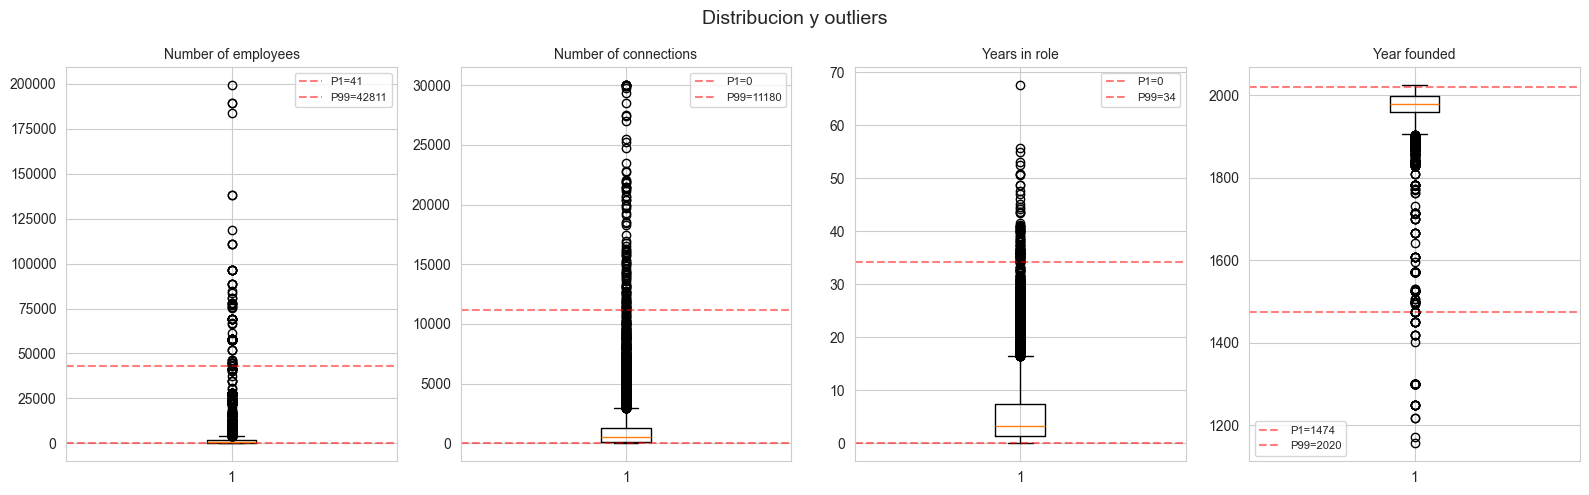

In [41]:
# Visualizar outliers en variables numericas clave
outlier_cols = ['Number of employees', 'Number of connections', 'Years in role', 'Year founded']
existing = [c for c in outlier_cols if c in df.columns and df[c].notna().sum() > 100]

if existing:
    fig, axes = plt.subplots(1, len(existing), figsize=(4*len(existing), 5))
    if len(existing) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, existing):
        data = df[col].dropna()
        ax.boxplot(data, vert=True)
        ax.set_title(col, fontsize=10)
        # Anotar percentiles extremos
        p1, p99 = data.quantile(0.01), data.quantile(0.99)
        ax.axhline(y=p1, color='r', linestyle='--', alpha=0.5, label=f'P1={p1:.0f}')
        ax.axhline(y=p99, color='r', linestyle='--', alpha=0.5, label=f'P99={p99:.0f}')
        ax.legend(fontsize=8)
    
    plt.suptitle('Distribucion y outliers', fontsize=14)
    plt.tight_layout()
    plt.show()

---
## Hallazgos principales

*(Se completan tras ejecutar el notebook)*

1. **Clase desbalanceada:** ~7.9% tasa de respuesta (865 positivos de 10,946)
2. **LinkedIn domina:** Mas respuestas por LinkedIn (552) que por email (313)
3. **FIT scores por producto:** Solo ai_FIT_DATA tiene datos suficientes; los demas son texto o nulos
4. **Columnas vacias:** Gender, Revenue, Jobs posted from LinkedIn -> eliminar
5. **Variables predictivas clave:** ai_SENIORITY, ai_DEPARTMENT, ai_Contact_score, Industry, Number of employees
6. **Metricas:** PR-AUC como metrica principal, Precision@k para evaluacion de negocio

### Proximo paso: NB03 - Feature Engineering + NLP